In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, binned_statistic_2d
import multiprocessing as mp

In [2]:
import niceplots
niceplots.initPlot()

import seaborn as sns
Cs = sns.color_palette("colorblind")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
Cp = sns.color_palette("Paired")
Cp

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [4]:
data = np.load("../data/test_powerspectra_nosn.npz")
k = data["kmode"]

In [5]:
dataf0 = np.load("../data/power_spectra_func01.npz")
[ki for ki in dataf0.keys()]

['kmode', 'phi', 'pgal', 'phixgal', 'phi_mod', 'pgal_mod', 'phixgal_mod']

In [6]:
# k - dataf0["kmode"]
# plt.hist(((dataf0["pgmod3d_arr"] - dataf0["pgmod3d_arr"].mean(0)) / dataf0["pgmod3d_arr"]).flatten())

In [7]:
from specs import *
from meer21cm import PowerSpectrum

ps = PowerSpectrum(
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    nu=nu_arr,
    ra_range=ra_range,
    dec_range=dec_range,
    # downscale the resolution along line-of-sight
    downres_factor_radial = 6,
    # downscale the resolution on the transverse plane
    downres_factor_transverse = 3,
    omega_hi = 5e-4,
    tracer_bias_1 = 1.5,
    tracer_bias_2 = 1.5,
    mean_amp_1 = 'average_hi_temp',
    sigma_v_1=5,
    sigma_v_2=5,
)

In [8]:
kmask = ~(k==0.0)
k = k[kmask]

kbinned = np.geomspace(k.min(), k.max(), 20)
kc = np.sqrt(kbinned[1:] * kbinned[:-1])

In [9]:
ps.get_enclosing_box()
np.mean(k - ps.kmode[kmask])

0.0

In [10]:
kx, ky, kz = ps.k_vec
notkmasksimple = np.logical_or(
    np.logical_or(
        np.array(kx)[:, None, None]==0, np.array(ky)[:, None]==0
    ),
    np.array(kz)==0,
)

kparr = ps.kmode * ps.mumode
kperp = ps.kmode * np.sqrt(1 - np.clip(ps.mumode**2,0,1))

kparrc = 0.5 * (kparabins[1:] + kparabins[:-1]) # Bin centers
kperpc = 0.5 * (kperpbins[1:] + kperpbins[:-1]) # Bin centers
k1dc = 0.5 * (k1dbins[1:] + k1dbins[:-1])


np.mean(np.array(notkmasksimple, dtype=int))

0.1270338856545753

In [11]:
N, _, _ = binned_statistic(k, [], "count", kbinned)
Nmask = ~(N==0)

In [12]:
def get_1d_power_sims(array):
    data = array[kmask]
    output, _, _ = binned_statistic(
        k, data, statistic="mean", bins=kbinned
    )
    return output

def get_cy_power_sims(array):
    data = array[~notkmasksimple]
    output, _, _, _ = binned_statistic_2d(
        kparr[~notkmasksimple], kperp[~notkmasksimple], data, statistic="mean", bins=(kparabins, kperpbins)
    )
    return output


In [14]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, dataf0["phi"]):
        ar.append(output)
P_HI_2df0 = np.array(ar).mean(0)

P_HI_mod_2df0 = get_cy_power_sims(dataf0["phi_mod"])

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data["phi"]):
        ar.append(output)
P_HI_2d = np.array(ar).mean(0)

P_HI_mod_2d = get_cy_power_sims(data["phi_mod"])

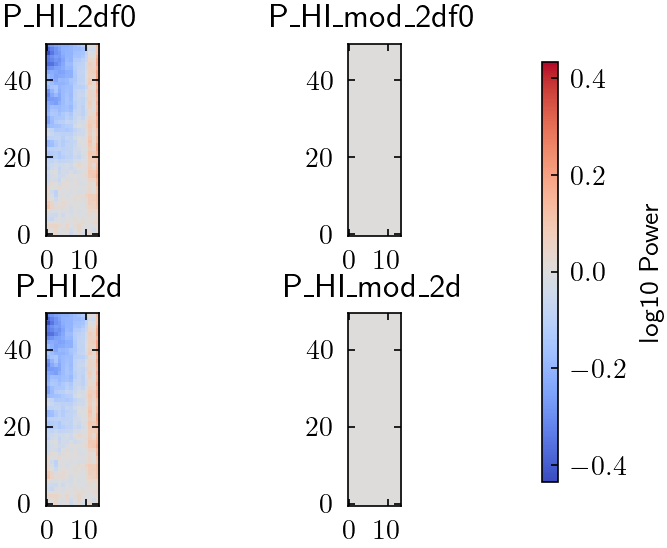

In [15]:
def safe_log(arr):
    return np.log10(np.where(arr > 0, arr, np.nan))

fields = [
    safe_log(P_HI_2df0),
    safe_log(P_HI_mod_2df0),
    safe_log(P_HI_2d),
    safe_log(P_HI_mod_2d),
]

titles = [
    "P_HI_2df0",
    "P_HI_mod_2df0",
    "P_HI_2d",
    "P_HI_mod_2d",
]

# Compute global vmin/vmax so all share the same colorbar scale
vmin = np.nanmin(fields - fields[1])
vmax = np.nanmax(fields - fields[1])
rmax = np.max([np.abs(vmin), np.abs(vmax)])

fig, axes = plt.subplots(2, 2)
fig.subplots_adjust(wspace=0.0, hspace=0.4)

for ax, field, title in zip(axes.flat, fields, titles):
    im = ax.imshow(field - fields[1], origin="lower", vmin=-rmax, vmax=rmax, cmap="coolwarm")
    ax.set_title(title)

# Add one shared colorbar
# leave space for colorbar
fig.subplots_adjust(right=0.88)

# create colorbar axis (far right, no overlap)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cax)

cbar.set_label("log10 Power")

plt.show()


In [16]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, dataf0["phi"]):
        ar.append(output)
P_HI_1df0 = np.array(ar).mean(0)

P_HI_mod_1df0 = get_1d_power_sims(dataf0["phi_mod"])

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["phi"]):
        ar.append(output)
P_HI_1d = np.array(ar).mean(0)

P_HI_mod_1d = get_1d_power_sims(data["phi_mod"])

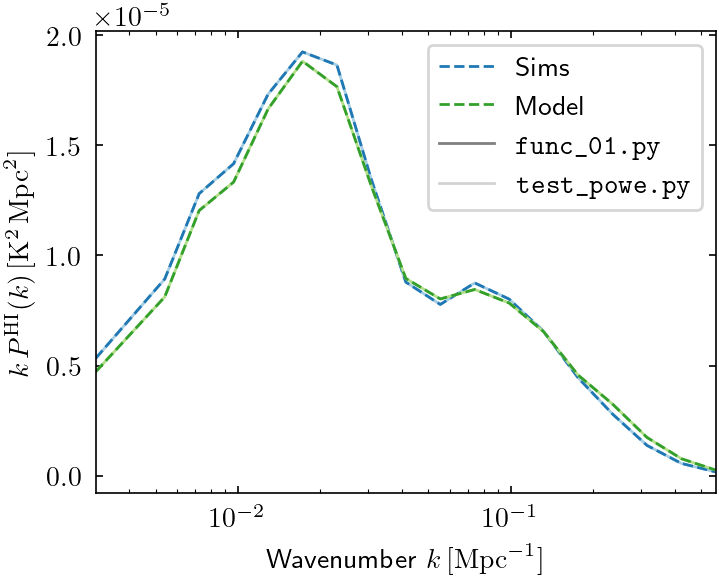

In [18]:
color = iter(Cp)
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1df0[Nmask], c=next(color), label="Sims", ls="--")

plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1df0[Nmask], c=next(color), label="Model", ls="--")


plt.plot([], [], c="gray", label=r"\texttt{func_01.py}")
plt.plot([], [], c="lightgray", label=r"\texttt{test_powe.py}")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{HI}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$")
plt.legend()


In [19]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, dataf0["pgal"]):
        ar.append(output)
P_HI_1df0 = np.array(ar).mean(0)

P_HI_mod_1df0 = get_1d_power_sims(dataf0["pgal_mod"])

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["pgal"]):
        ar.append(output)
P_HI_1d = np.array(ar).mean(0)

P_HI_mod_1d = get_1d_power_sims(data["pgal_mod"])

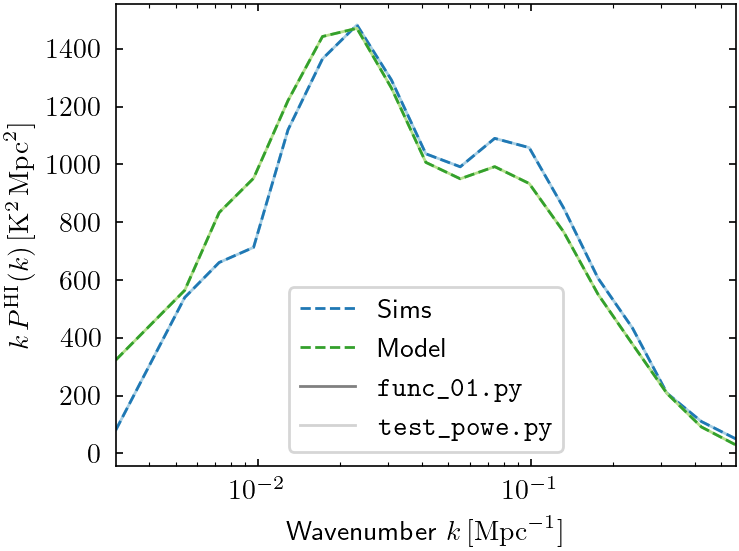

In [20]:
color = iter(Cp)
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1df0[Nmask], c=next(color), label="Sims", ls="--")

plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1df0[Nmask], c=next(color), label="Model", ls="--")


plt.plot([], [], c="gray", label=r"\texttt{func_01.py}")
plt.plot([], [], c="lightgray", label=r"\texttt{test_powe.py}")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{HI}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$")
plt.legend()


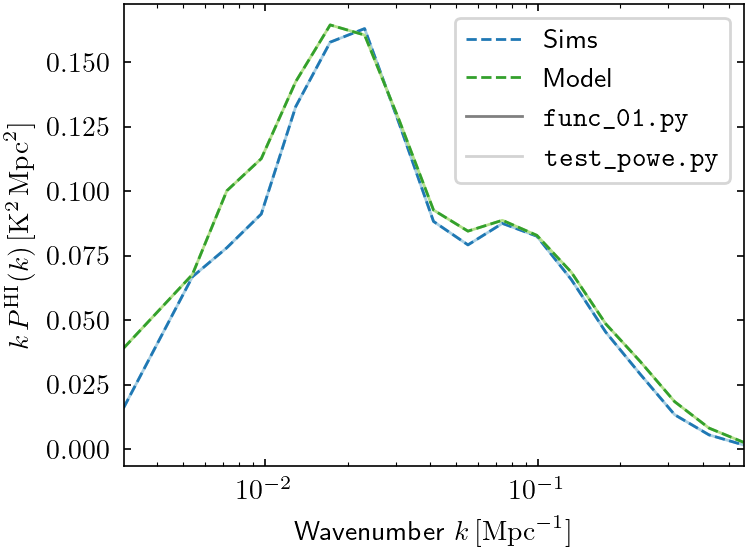

In [21]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, dataf0["phixgal"]):
        ar.append(output)
P_HI_1df0 = np.array(ar).mean(0)

P_HI_mod_1df0 = get_1d_power_sims(dataf0["phixgal_mod"])

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["phixgal"]):
        ar.append(output)
P_HI_1d = np.array(ar).mean(0)

P_HI_mod_1d = get_1d_power_sims(data["phixgal_mod"])

color = iter(Cp)
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1df0[Nmask], c=next(color), label="Sims", ls="--")

plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1df0[Nmask], c=next(color), label="Model", ls="--")


plt.plot([], [], c="gray", label=r"\texttt{func_01.py}")
plt.plot([], [], c="lightgray", label=r"\texttt{test_powe.py}")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{HI}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$")
plt.legend()


In [ ]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, dataf0["pg3d_arr"]):
        ar.append(output)
P_gal_1df0 = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, dataf0["pgmod3d_arr"]):
        ar.append(output)
P_gal_mod_1df0 = np.array(ar).mean(0)

ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["pgal"]):
        ar.append(output)
P_gal_1d = np.array(ar).mean(0)

P_gal_mod_1d = get_1d_power_sims(data["pgal_mod"])

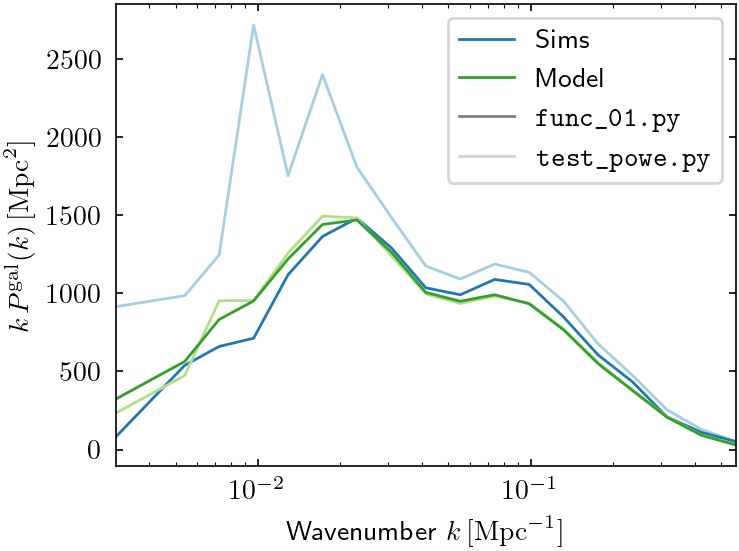

In [ ]:
color = iter(Cp)
plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_1df0[Nmask], c=next(color), label="Sims")

plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_mod_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_mod_1df0[Nmask], c=next(color), label="Model")


plt.plot([], [], c="gray", label=r"\texttt{func_01.py}")
plt.plot([], [], c="lightgray", label=r"\texttt{test_powe.py}")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{gal}(k)\,[\mathrm{Mpc}^{2}]$")
plt.legend()

In [ ]:
color = iter(Cp)
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_1df0[Nmask], c=next(color), label="Sims")

plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1d[Nmask], c=next(color))
plt.semilogx(kc[Nmask], kc[Nmask] * P_HI_mod_1df0[Nmask], c=next(color), label="Model")


plt.plot([], [], c="gray", label=r"\texttt{func_01.py}")
plt.plot([], [], c="lightgray", label=r"\texttt{test_powe.py}")

plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{HI}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^{2}]$")
plt.legend()

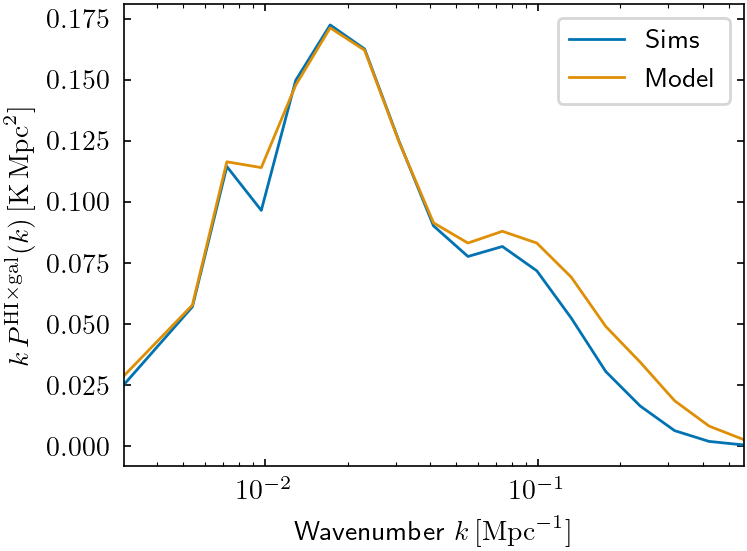

In [ ]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["phixgal"]):
        ar.append(output)
P_hixgal_1d = np.array(ar).mean(0)

P_hixgal_mod_1d = get_1d_power_sims(data["phixgal_mod"])

color = iter(Cs)
plt.semilogx(kc[Nmask], kc[Nmask] * P_hixgal_1d[Nmask], c=next(color), label="Sims")
plt.semilogx(kc[Nmask], kc[Nmask] * P_hixgal_mod_1d[Nmask], c=next(color), label="Model")
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^{\mathrm{HI}\times\mathrm{gal}}(k)\,[\mathrm{K}\,\mathrm{Mpc}^{2}]$")
plt.legend()

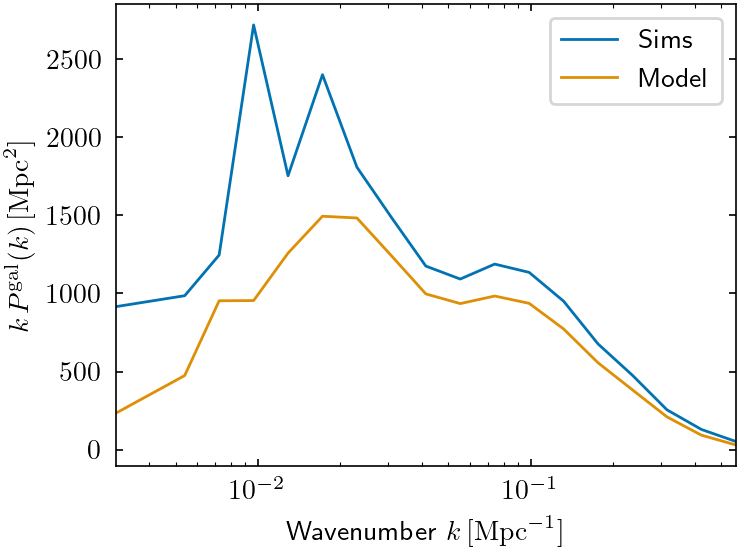

In [ ]:
ar = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["pgal"]):
        ar.append(output)
P_gal_1d = np.array(ar).mean(0)

P_gal_mod_1d = get_1d_power_sims(data["pgal_mod"])

color = iter(Cs)
plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_1d[Nmask], c=next(color), label="Sims")
plt.semilogx(kc[Nmask], kc[Nmask] * P_gal_mod_1d[Nmask], c=next(color), label="Model")


plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$k\,P^\mathrm{gal}(k)\,[\mathrm{Mpc}^{2}]$")
plt.legend()